In [1]:
import os
import pickle
import numpy as np
import os.path as osp
from tqdm import tqdm
from pprint import pprint
from datetime import datetime
import matplotlib.pyplot as plt

import torch
import tensorflow as tf
from tensorflow.keras import losses
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model


from src.models import CNNtf
import src.cf_methods.countergan.utils  as cutils
from src.cf_methods.countergan import create_convolutional_autoencoder

tf.experimental.numpy.experimental_enable_numpy_behavior()

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
from src.utils import seed_tf

seed_tf()

Loading MNIST data

In [3]:
def convert_multiclass_to_binary(x, y, initial_class, target_class, class_encoding):
    init_class_ind = tf.where(y==initial_class)
    target_class_ind = tf.where(y==target_class)

    y_bin = tf.concat([y[init_class_ind], y[target_class_ind]], axis=0)
    x_bin = tf.concat([x[init_class_ind], x[target_class_ind]], axis=0)

    y_bin_encoded = tf.where(y_bin==initial_class, 
                             class_encoding[initial_class], 
                             class_encoding[target_class])

    return x_bin, y_bin_encoded 

In [4]:
INIT_CLASS = 1
DESIRED_CLASS = 8  # This is the target class that the generator will learn to synthetize
N_CLASSES = 2

class_encodings = {INIT_CLASS: 0, DESIRED_CLASS: 1}
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = (x_train / 255.).astype("float32")
x_test = (x_test / 255.).astype("float32")

In [5]:
X_train, y_train = convert_multiclass_to_binary(x_train, y_train, INIT_CLASS, DESIRED_CLASS, class_encodings) 
X_test, y_test = convert_multiclass_to_binary(x_test, y_test, INIT_CLASS, DESIRED_CLASS, class_encodings)

X_train = tf.transpose(X_train, perm=(0, 2, 3, 1))
X_test = tf.transpose(X_test, perm=(0, 2, 3, 1))

y_train_encoded = to_categorical(y_train, N_CLASSES)
y_test_encoded = to_categorical(y_test, N_CLASSES)

## Train AE

In [ ]:
def add_noise(x, noise_factor=0.5):
    noise_factor = 0.5
    x_noisy = x + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    x_noisy = np.clip(x_noisy, 0., 1.)
    return x_noisy

autoencoder = create_convolutional_autoencoder(in_shape=(28, 28, 1))
training = autoencoder.fit(
    add_noise(X_train), X_train, epochs=5, batch_size=32, shuffle=True,
    verbose=0, validation_data=(X_test, X_test)
)
print(f"Training loss: {training.history['loss'][-1]:.4f}")
print(f"Validation loss: {training.history['val_loss'][-1]:.4f}")

# Compute the reconstruction error of noise data
samples = np.random.uniform(low=0.0, high=1.0, size=(1000, 28, 28, 1))
reconstruction_error_noise = cutils.compute_reconstruction_error(samples, autoencoder)

# Save and print the autoencoder metrics
reconstruction_error = cutils.compute_reconstruction_error(X_test, autoencoder)
autoencoder_metrics = {
    "reconstruction_error": cutils.format_metric(reconstruction_error),
    "reconstruction_error_noise": cutils.format_metric(reconstruction_error_noise),
}

pprint(autoencoder_metrics)


In [ ]:
weights_path = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
file_name = f'binary_autoencoder_mnist_{INIT_CLASS}_{DESIRED_CLASS}.h5'
autoencoder.save(osp.join(weights_path, file_name))

d:\PycharmProjects\CF-Robustness-Benchmark\venv\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Load a classifier and AE

Load classifier

In [6]:
saved_model_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\binary\checkpoints'
file_name = f'classifier_mnist_{INIT_CLASS}_{DESIRED_CLASS}.keras'

baseline_classifier = load_model(osp.join(saved_model_dir, file_name), 
                        custom_objects={'CNNtf': CNNtf})

y_prob = baseline_classifier.predict(X_test)

accuracy = (y_prob.argmax(axis=1) == y_test[:, 0]).numpy().mean()
print(f"Classifier accuracy test: {accuracy:.3%}")

66/66 [==============================] - 1s 4ms/step
Classifier accuracy test: 99.858%


Load AE

In [7]:
weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
file_name = f'binary_autoencoder_mnist_{INIT_CLASS}_{DESIRED_CLASS}.h5'
autoencoder = load_model(osp.join(weights_dir, file_name), 
                         custom_objects={'mse': losses.mse})
reconstruction_error_test = cutils.compute_reconstruction_error(X_test, autoencoder)
print(f"AE average reconstruction error: {reconstruction_error_test.mean():.3f}")

AE average reconstruction error: 3.730


# Training of CounterGAN

In [17]:
from src.cf_methods.countergan import create_generator, create_discriminator, define_countergan

In [24]:
generator = create_generator(in_shape=(28, 28, 1))
discriminator = create_discriminator(in_shape=(28, 28, 1))

In [ ]:
def train_countergan(n_discriminator_steps, n_generator_steps, n_training_iterations,
                     classifier, discriminator, generator, batches,
                     weighted_version=False, negative_batches=None, positive_batches=None,
                     ):
    """ Main function: train the CounteRGAN"""

    def check_divergence(x_generated):
        return np.all(np.isnan(x_generated))

    def print_training_information(generator, classifier, X_test, iteration):
        X_gen = generator.predict(X_test)
        clf_pred_test = classifier.predict(X_test) # y_M 
        clf_pred = classifier.predict(X_gen)  # y_cf

        delta_clf_pred = (clf_pred - clf_pred_test)[:, class_encodings[DESIRED_CLASS]]
        y_target = to_categorical([class_encodings[DESIRED_CLASS]] * len(clf_pred), num_classes=N_CLASSES)
        print('='*88)
        print(f"Training iteration {iteration} at {datetime.now()}")

        # Plot original images, residuals, and generated images
        sample_indices  = np.random.choice(len(X_test), 10, replace=False)
        residuals = X_gen[sample_indices]-X_test[sample_indices]

        save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary\visualizations_1_7'
        cutils.plot_generated_images(X_test[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'original_images_iter_{iteration}.png'))
        cutils.plot_generated_images(residuals, n_plots=10, n_plots_per_row=10, residuals=True, save_path=osp.join(save_dir, f'residuals_iter_{iteration}.png'))
        cutils.plot_generated_images(X_gen[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'generated_images_iter_{iteration}.png'))

        reconstruction_error = np.mean(cutils.compute_reconstruction_error(X_gen, autoencoder))
        print(f"Autoencoder reconstruction error (infinity to 0): {reconstruction_error:.3f}")
        print(f"Counterfactual prediction gain (0 to 1): {delta_clf_pred.mean():.3f}")
        print(f"Sparsity (L1, infinity to 0): {np.mean(np.abs(X_gen-X_test)):.3f}")


    countergan = define_countergan(generator, discriminator, classifier)

    for iteration in tqdm(range(n_training_iterations)):
        # Periodically print and plot training information
        if (iteration % 300 == 0) or (iteration == n_training_iterations - 1):
            print_training_information(generator, classifier, X_test, iteration)
            models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary\checkpoints_1_7'
            generator.save(osp.join(models_save_dir, f'generator_1_7_iter_{iteration}.keras'))
            discriminator.save(osp.join(models_save_dir, f'discriminator_1_7_iter_{iteration}.keras'))

        # Train the discriminator
        discriminator.trainable = True
        for _ in range(n_discriminator_steps):
            x_fake_input, _ = next(batches)
            x_real = x_fake_input

            x_fake = cutils.generate_fake_samples(x_fake_input, generator)

            x_batch = np.concatenate([x_real, x_fake])
            y_batch = np.concatenate([np.ones(len(x_real)), np.zeros(len(x_fake))])

            # Shuffle real and fake examples
            p = np.random.permutation(len(y_batch))
            x_batch, y_batch = x_batch[p], y_batch[p]
            discriminator.train_on_batch(x_batch, y_batch)

        # Train the generator
        discriminator.trainable = False
        for _ in range(n_generator_steps):
            x_fake_input, _ = next(batches)
            y_fake = np.ones(len(x_fake_input))
            y_target = to_categorical([class_encodings[DESIRED_CLASS]] * len(x_fake_input),
                                          num_classes=N_CLASSES)
            
            countergan.train_on_batch(x_fake_input, [y_fake, y_target])
    
    return countergan

In [28]:
batches = cutils.infinite_data_stream(X_train, y_train, batch_size=128)

  0%|          | 0/10000 [00:00<?, ?it/s]

68/68 [==============================] - 0s 7ms/step
Training iteration 0 at 2025-06-19 00:42:08.124600


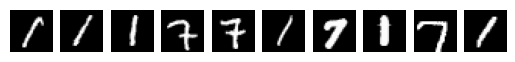

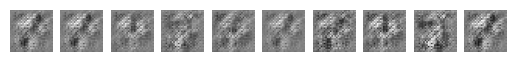

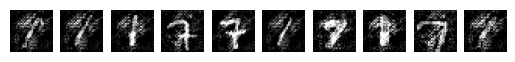

Autoencoder reconstruction error (infinity to 0): 6.152
Counterfactual prediction gain (0 to 1): 5.931
Sparsity (L1, infinity to 0): 0.162


  3%|▎         | 300/10000 [09:08<4:47:25,  1.78s/it]

68/68 [==============================] - 0s 3ms/step
Training iteration 300 at 2025-06-19 00:51:14.874564


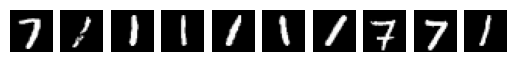

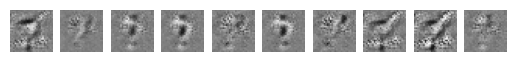

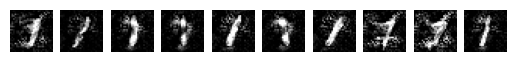

Autoencoder reconstruction error (infinity to 0): 5.069
Counterfactual prediction gain (0 to 1): -1.837
Sparsity (L1, infinity to 0): 0.136


  6%|▌         | 600/10000 [18:17<4:47:33,  1.84s/it]

68/68 [==============================] - 0s 3ms/step
Training iteration 600 at 2025-06-19 01:00:24.367693


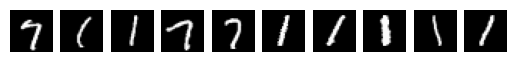

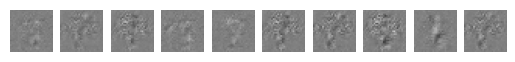

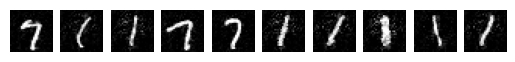

Autoencoder reconstruction error (infinity to 0): 2.906
Counterfactual prediction gain (0 to 1): 4.769
Sparsity (L1, infinity to 0): 0.058


  9%|▉         | 900/10000 [28:26<5:13:42,  2.07s/it]

68/68 [==============================] - 0s 4ms/step
Training iteration 900 at 2025-06-19 01:10:33.356710


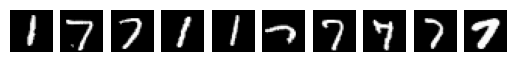

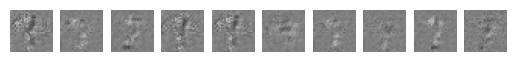

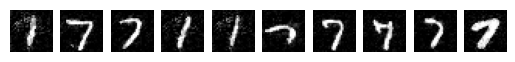

Autoencoder reconstruction error (infinity to 0): 3.333
Counterfactual prediction gain (0 to 1): 6.344
Sparsity (L1, infinity to 0): 0.073


 12%|█▏        | 1200/10000 [40:44<7:05:54,  2.90s/it]

68/68 [==============================] - 0s 4ms/step
Training iteration 1200 at 2025-06-19 01:22:51.775808


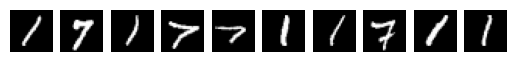

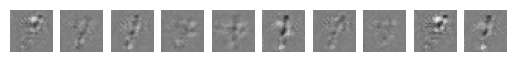

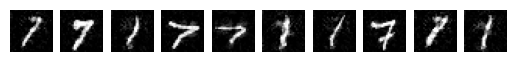

Autoencoder reconstruction error (infinity to 0): 3.012
Counterfactual prediction gain (0 to 1): 5.478
Sparsity (L1, infinity to 0): 0.062


 15%|█▌        | 1500/10000 [56:37<8:02:34,  3.41s/it] 

68/68 [==============================] - 0s 4ms/step
Training iteration 1500 at 2025-06-19 01:38:45.436873


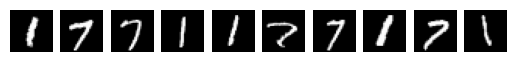

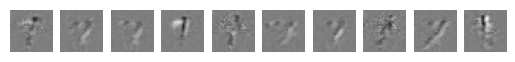

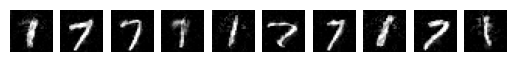

Autoencoder reconstruction error (infinity to 0): 2.848
Counterfactual prediction gain (0 to 1): 5.429
Sparsity (L1, infinity to 0): 0.063


 18%|█▊        | 1800/10000 [1:14:39<8:27:25,  3.71s/it]

68/68 [==============================] - 0s 4ms/step
Training iteration 1800 at 2025-06-19 01:56:47.025904


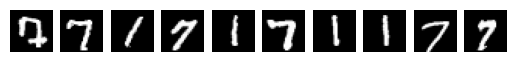

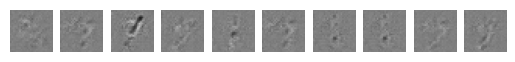

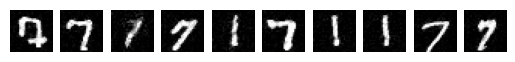

Autoencoder reconstruction error (infinity to 0): 2.625
Counterfactual prediction gain (0 to 1): 3.532
Sparsity (L1, infinity to 0): 0.051


 21%|██        | 2100/10000 [1:35:04<9:29:52,  4.33s/it] 

68/68 [==============================] - 0s 5ms/step
Training iteration 2100 at 2025-06-19 02:17:13.029993


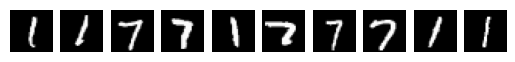

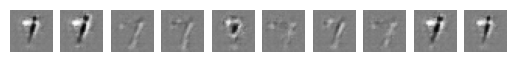

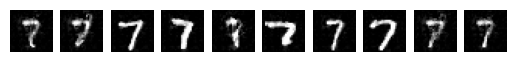

Autoencoder reconstruction error (infinity to 0): 2.962
Counterfactual prediction gain (0 to 1): 8.063
Sparsity (L1, infinity to 0): 0.074


 24%|██▍       | 2400/10000 [1:57:29<10:20:17,  4.90s/it]

68/68 [==============================] - 0s 5ms/step
Training iteration 2400 at 2025-06-19 02:39:38.242055


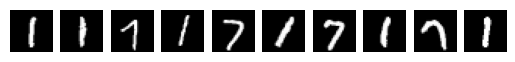

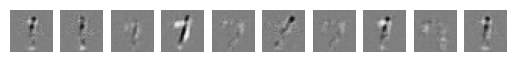

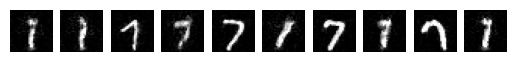

Autoencoder reconstruction error (infinity to 0): 2.643
Counterfactual prediction gain (0 to 1): 5.205
Sparsity (L1, infinity to 0): 0.056


 27%|██▋       | 2700/10000 [2:20:42<9:15:01,  4.56s/it] 

68/68 [==============================] - 0s 6ms/step
Training iteration 2700 at 2025-06-19 03:02:51.270235


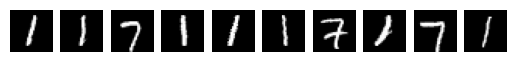

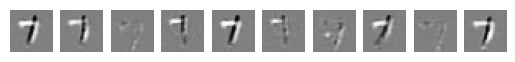

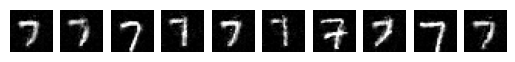

Autoencoder reconstruction error (infinity to 0): 2.603
Counterfactual prediction gain (0 to 1): 6.802
Sparsity (L1, infinity to 0): 0.066


 30%|███       | 3000/10000 [2:44:37<9:23:25,  4.83s/it] 

68/68 [==============================] - 1s 8ms/step
Training iteration 3000 at 2025-06-19 03:26:46.680623


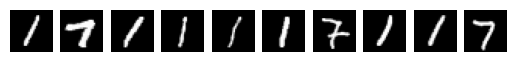

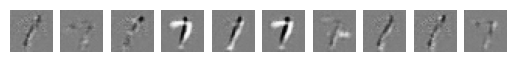

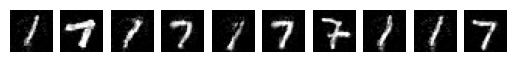

Autoencoder reconstruction error (infinity to 0): 2.601
Counterfactual prediction gain (0 to 1): 6.815
Sparsity (L1, infinity to 0): 0.065


 33%|███▎      | 3300/10000 [3:10:25<10:17:08,  5.53s/it]

68/68 [==============================] - 0s 7ms/step
Training iteration 3300 at 2025-06-19 03:52:34.552153


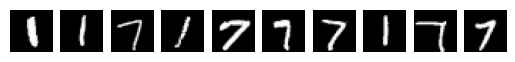

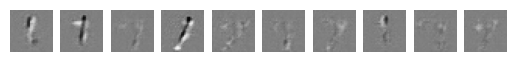

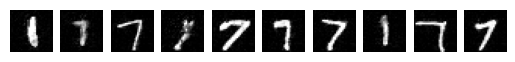

Autoencoder reconstruction error (infinity to 0): 2.484
Counterfactual prediction gain (0 to 1): 4.225
Sparsity (L1, infinity to 0): 0.051


 36%|███▌      | 3600/10000 [3:38:10<10:12:20,  5.74s/it]

68/68 [==============================] - 1s 9ms/step
Training iteration 3600 at 2025-06-19 04:20:19.913995


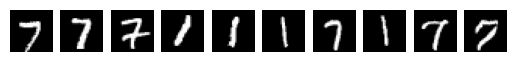

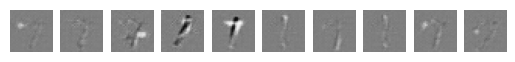

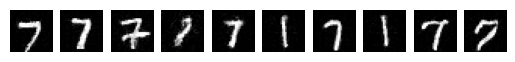

Autoencoder reconstruction error (infinity to 0): 2.483
Counterfactual prediction gain (0 to 1): 5.153
Sparsity (L1, infinity to 0): 0.054


 39%|███▉      | 3900/10000 [4:09:41<13:32:01,  7.99s/it]

68/68 [==============================] - 1s 17ms/step
Training iteration 3900 at 2025-06-19 04:51:55.973446


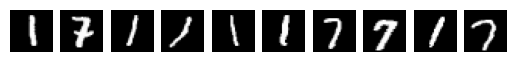

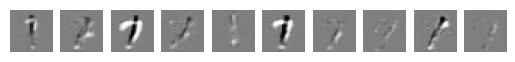

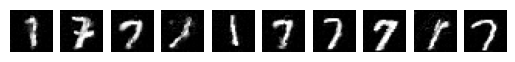

Autoencoder reconstruction error (infinity to 0): 2.471
Counterfactual prediction gain (0 to 1): 5.871
Sparsity (L1, infinity to 0): 0.059


 40%|███▉      | 3974/10000 [4:22:08<19:04:50, 11.40s/it]

In [ ]:
method_name = "countergan"
countergan = train_countergan(2, 3, 10000, baseline_classifier, discriminator, generator, batches)

# Evaluation of CounterGAN

Load perts of CounteRGAN

In [8]:
models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary\checkpoints_1_8'

generator_fname = 'generator_1_8_iter_5000.keras' #'generator_1_7_iter_3900.keras'
discriminator_fname = 'discriminator_1_8_iter_5000.keras' #'discriminator_1_7_iter_3900.keras'


generator = load_model(osp.join(models_save_dir, generator_fname))
discriminator = load_model(osp.join(models_save_dir, discriminator_fname))

In [9]:
class_ind = np.where(y_test == class_encodings[INIT_CLASS])[0]
factuals = X_test[class_ind]
labels =  y_test[class_ind]

print('Total number of factual instances: ', factuals.shape[0])

Total number of factual instances:  1135


In [10]:
predictions = tf.argmax(baseline_classifier.predict(factuals, verbose=0), axis=1)
_, valid_indices = np.where([predictions == tf.argmax(labels, axis=1)])
factuals = tf.gather(factuals, valid_indices)
labels = tf.gather(labels, valid_indices) 

## Robustness Evaluation

### Local Instability

In [11]:
from functools import reduce
from src.evaluation.local_instability import perturb_sample
from src.evaluation.local_instability import calculate_sparsity, calculate_ssim
from src.utils.visualization import plot_boxplot

In [12]:
cfes = generator.predict(factuals, verbose=0)

In [13]:
noise_levels = [0.005, 0.01, 0.015, 0.02, 0.025]

In [14]:
factuals_pert = {}
pert_indices = {}

for noise_level in noise_levels:
    pert_sample = perturb_sample(factuals, n_samples=1, epsilon=noise_level, 
                                 type='uniform', channels_first=False) #.permute(0, 2, 3, 1).numpy()
    pert_sample = pert_sample.squeeze(1)
    factuals_pert[noise_level] = pert_sample

    # Check whether perturbed instances lead to the same class prediction
    predictions = tf.argmax(baseline_classifier.predict(pert_sample, verbose=0), axis=1)
   
    # targets = tf.argmax(labels, axis=1)
    indices = np.where([predictions == labels])[1]
    pert_indices[noise_level] = indices

    print('Number of valid perturbed factuals for the added noise level {}: {}'.format(noise_level, factuals_pert[noise_level].shape[0]))

Number of valid perturbed factuals for the added noise level 0.005: 1134
Number of valid perturbed factuals for the added noise level 0.01: 1134
Number of valid perturbed factuals for the added noise level 0.015: 1134
Number of valid perturbed factuals for the added noise level 0.02: 1134
Number of valid perturbed factuals for the added noise level 0.025: 1134


In [15]:
n = 100
final_indices = reduce(np.intersect1d, list(pert_indices.values()))[:n]
factuals = tf.gather(factuals, final_indices) 
labels = tf.gather(labels, final_indices)

cfes = tf.gather(cfes, final_indices).numpy()
factuals_pert = {k : tf.gather(v, final_indices) for k, v in factuals_pert.items()}
cfes_pert =  {k: generator.predict(v, verbose=0) for k, v in factuals_pert.items()} 

In [16]:
cfes_pred = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
validity = np.where(cfes_pred == class_encodings[DESIRED_CLASS])[0].shape[0] / cfes.shape[0]
print(f'Validity of the generated CFEs: {validity:.2%}')

Validity of the generated CFEs: 10.00%


In [17]:
validity_list = []
for noise_level in noise_levels:
    cfes_pert_pred = tf.argmax(baseline_classifier.predict(cfes_pert[noise_level], verbose=0), axis=1)
    validity = len(np.where(cfes_pert_pred == class_encodings[DESIRED_CLASS])[0]) / len(cfes)
    print(f'Validity of the generated CFEs under the noise level {noise_level}: {validity:.2%}')
    
    validity_list.append(validity)

output_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_binary'
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_validity.pkl'), 'wb') as f:
    pickle.dump(validity_list, f)

Validity of the generated CFEs under the noise level 0.005: 12.00%
Validity of the generated CFEs under the noise level 0.01: 12.00%
Validity of the generated CFEs under the noise level 0.015: 12.00%
Validity of the generated CFEs under the noise level 0.02: 13.00%
Validity of the generated CFEs under the noise level 0.025: 13.00%


In [18]:
# Check for the bounded noise

for noise_level in noise_levels:
    # diffs = np.abs(factuals - factuals_pert[noise_level])
    diffs = np.linalg.norm((factuals - factuals_pert[noise_level]).reshape(-1, 1), ord=np.Inf)
    print('Maximum difference between original and perturbed factuals for the noise level {:.2f}: {}'.format(noise_level, diffs))

Maximum difference between original and perturbed factuals for the noise level 0.01: 0.004999919723568614
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.009998966921931309
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.014999904159805632
Maximum difference between original and perturbed factuals for the noise level 0.02: 0.019999745383586152
Maximum difference between original and perturbed factuals for the noise level 0.03: 0.0249998936686038


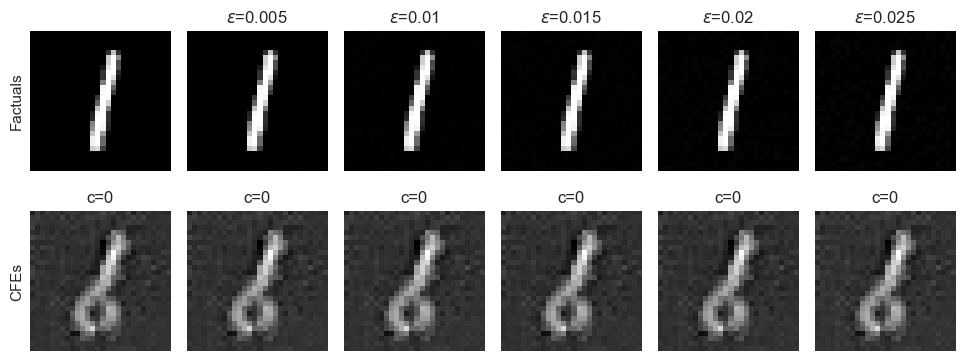

In [19]:
plt.style.use("seaborn-v0_8")

ind = 90
factuals_pert_list = [factuals_pert[noise_level][ind] for noise_level in noise_levels]
cfes_pert_list = [cfes_pert[noise_level][ind] for noise_level in noise_levels]

factuals_vis = [factuals[ind]] + factuals_pert_list
cfes_vis = [cfes[ind]] + cfes_pert_list

n_rows = 2
n_cols = len(factuals_vis)

_, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharex=True, sharey=True)
for j in range(n_cols):
    axs[0, j].imshow(factuals_vis[j] , cmap="gray")
    if noise_levels and j > 0:
        noise = noise_levels[j-1]
        axs[0, j].set_title("$\\epsilon$={}".format(noise))

    axs[1, j].imshow(cfes_vis[j], cmap="gray")
    pred = tf.argmax(baseline_classifier.predict(tf.expand_dims(cfes_vis[j], axis=0), verbose=0), axis=1).numpy()
    axs[1, j].set_title(f'c={DESIRED_CLASS if pred == class_encodings[DESIRED_CLASS] else class_encodings[INIT_CLASS]}')
    
    if j == 0:
        axs[0, j].set_ylabel('Factuals')
        axs[1, j].set_ylabel('CFEs')

plt.tight_layout()
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
plt.show()

In [20]:
# Calculating L1 distance between the explanations of original and perturbed instances
l1_list = []
ssim_list = []


for i, noise_level in tqdm(enumerate(cfes_pert.keys())):
    l1_temp = []
    ssim_temp = []

    cfs_pert = cfes_pert[noise_level]

    for i in range(cfes_pert[noise_level].shape[0]): 

        l1_distance = calculate_sparsity(cfes[i].flatten(), cfes_pert[noise_level][i].flatten()).item()
        l1_temp.append(l1_distance)

        ssim = calculate_ssim(torch.Tensor(cfes[i]).permute(2, 0, 1).unsqueeze(0), 
                              torch.Tensor(cfes_pert[noise_level][i]).permute(2, 0, 1).unsqueeze(0)).item()
        ssim_temp.append(ssim)

    print(f'Average Instability (L1) for the set of counterfactuals of size : {np.mean(l1_temp)}')    
    l1_list.append(l1_temp)
    
    print(f'Average SSIM for the set of counterfactuals of size : {np.mean(ssim_temp)}')    
    ssim_list.append(ssim_temp)

2it [00:00,  8.01it/s]

Average Instability (L1) for the set of counterfactuals of size : 1.4218273961544037
Average SSIM for the set of counterfactuals of size : 0.9996921694278718
Average Instability (L1) for the set of counterfactuals of size : 2.8464774966239927
Average SSIM for the set of counterfactuals of size : 0.9987564617395401


4it [00:00,  8.81it/s]

Average Instability (L1) for the set of counterfactuals of size : 4.296105422973633
Average SSIM for the set of counterfactuals of size : 0.9971642857789993
Average Instability (L1) for the set of counterfactuals of size : 5.7251354551315305
Average SSIM for the set of counterfactuals of size : 0.9949320733547211


5it [00:00,  8.53it/s]

Average Instability (L1) for the set of counterfactuals of size : 7.131646461486817
Average SSIM for the set of counterfactuals of size : 0.9924042636156082


In [21]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_li_l1.pkl'), 'wb') as f:
    pickle.dump(l1_list, f)

with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_ssim.pkl'), 'wb') as f:
    pickle.dump(ssim_list, f)

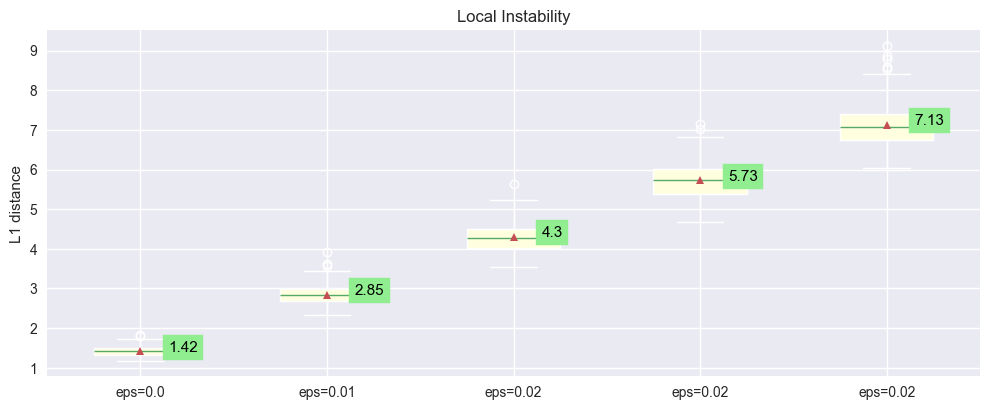

In [22]:
plt.style.use("seaborn-v0_8")

plt.rcParams['figure.figsize'] = [10, 4]

plot_boxplot(data=l1_list, mean_values=[np.round(np.mean(inst),2) for inst in l1_list],
             tick_labels=[f'eps={np.round(noise_level, 2)}' for noise_level in noise_levels],
             y_label='L1 distance', colors=['lightyellow'], title='Local Instability')

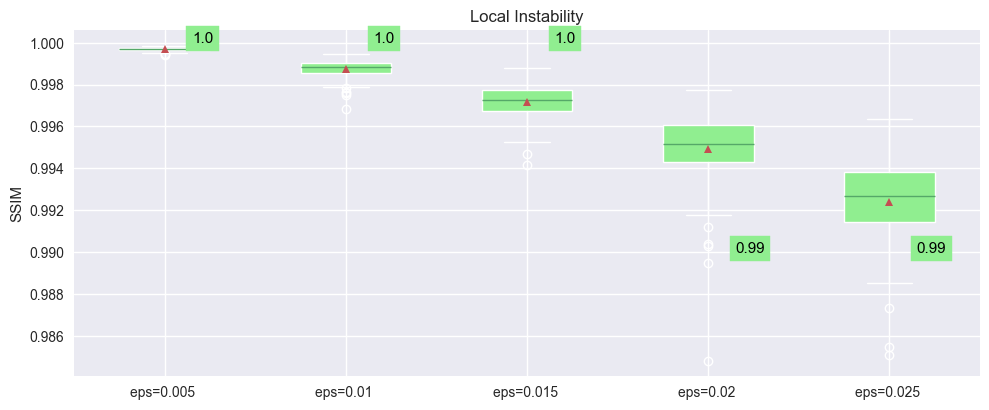

In [23]:
plot_boxplot(data=ssim_list, mean_values=[np.round(np.mean(inst),2) for inst in ssim_list],
             tick_labels=[f'eps={noise_level} ' for noise_level in noise_levels],
             y_label='SSIM', colors=['lightgreen'], title='Local Instability')

### Local Lipschitz Continuity

In [24]:
original_points = factuals
original_cfes = cfes
print("Are the lengths of initial points (factuals) and CFEs generated for them equal :", original_cfes.shape[0] == original_points.shape[0])

Are the lengths of initial points (factuals) and CFEs generated for them equal : True


In [25]:
noise_magnitude = 0.01

lip_estimates = []
n_samples = 30

for original_point, original_cfe in tqdm(zip(original_points[:30], original_cfes[:30])):

    neighbor_points = perturb_sample(original_point, n_samples=n_samples, 
                                     epsilon=noise_magnitude, type='uniform', 
                                     channels_first=False) 
    neighbor_points = neighbor_points.squeeze(0)
    neighbor_cfes = generator.predict(neighbor_points, verbose=False)

    lip_estimate = 0
    for m, p in zip(neighbor_cfes, neighbor_points):
        num = np.linalg.norm((original_cfe - m).flatten(), ord=2) 
        denom = np.linalg.norm((original_point.numpy() - p).flatten(), ord=2)
        lip = num / denom
        lip_estimate = max(lip, lip_estimate)
 
    lip_estimates.append(lip_estimate)


30it [00:01, 16.30it/s]


In [26]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_lle.pkl'), 'wb') as f:
    pickle.dump(lip_estimates, f)

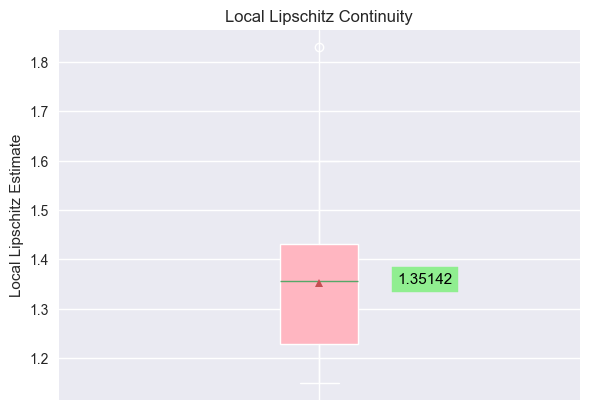

In [27]:
plt.rcParams['figure.figsize'] = [6, 4]
plot_boxplot(data=lip_estimates, mean_values=[np.round(np.mean(lip_estimates), 5)],
             tick_labels=[''],
             y_label='Local Lipschitz Estimate', colors=['lightpink'], title='Local Lipschitz Continuity')

### Invalidation Rate

Weights reinitialization

In [28]:
classifiers_weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\binary\checkpoints\mc_1_8_tf'
classifiers_list = []
for clf_fname in os.listdir(classifiers_weights_dir):
    cnn_perturbed = load_model(osp.join(classifiers_weights_dir, clf_fname), 
                            custom_objects={'CNNtf': CNNtf})
    classifiers_list.append(cnn_perturbed)

    logits = cnn_perturbed.predict(X_test)
    accuracy = (logits.argmax(axis=1) == y_test[:, 0]).numpy().mean()
    print(f"Classifier accuracy test: {accuracy:.3%}")

66/66 [==============================] - 0s 3ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 0s 4ms/step
Classifier accuracy test: 99.478%
66/66 [==============================] - 0s 4ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 0s 3ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 0s 3ms/step
Classifier accuracy test: 100.000%
66/66 [==============================] - 0s 4ms/step
Classifier accuracy test: 100.000%
66/66 [==============================] - 0s 3ms/step
Classifier accuracy test: 100.000%
66/66 [==============================] - 0s 4ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 0s 4ms/step
Classifier accuracy test: 99.953%
66/66 [==============================] - 0s 4ms/step
Classifier accuracy test: 99.953%


Evaluate IR only for the valid explanations for the baseline classifier

In [29]:
predictions = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
indices = np.where(predictions == class_encodings[DESIRED_CLASS])[0]
cfes_subsample = tf.gather(cfes, indices)
cfes_subsample.shape

validity = len(np.where(predictions == class_encodings[DESIRED_CLASS])[0]) / len(cfes)
print(f'Validity of the generated CFEs for correctly classified instances: {validity:.2%}')

Validity of the generated CFEs for correctly classified instances: 10.00%


In [30]:
invalidation_rate_list = []
validity_list = []
total_cfs = cfes_subsample.shape[0]


for i, classifier in enumerate(classifiers_list):
    invalidation_rate = 0

    baseline_pred = tf.argmax(baseline_classifier.predict(cfes_subsample, verbose=0), axis=1)
    alternative_pred = tf.argmax(classifier.predict(cfes_subsample, verbose=0), axis=1)

    invalidation_rate_list.append(baseline_pred != alternative_pred)

inv_rate_array = np.asarray(invalidation_rate_list)
inv_rate_avg = inv_rate_array.mean(axis=0)
var_avg = 1 - inv_rate_array.mean(axis=0)
print("Average IR of the sample among {} models: {} ({:.3f})".format(len(classifiers_list), inv_rate_avg.mean(), inv_rate_avg.std()))
print("Average VaR of the sample among {} models: {} ({:.3f})".format(len(classifiers_list), var_avg.mean(), var_avg.std()))

Average IR of the sample among 10 models: 0.15 (0.163)
Average VaR of the sample among 10 models: 0.85 (0.163)


### Stability 

In [34]:
k = 1000
average_stability_list = []


for i, classifier in enumerate(classifiers_list):
    stability_list = []
    stability = 0

    original_logits = classifier.predict(cfes_subsample, verbose=0)
    # To calculate stability of only valid CFE, they need to be identified
    valid_cfs_ind = tf.where(original_logits.argmax(axis=1) == class_encodings[DESIRED_CLASS])[:, 0]
    print('Number of valid CFEs for the model {}: {}'.format(i, valid_cfs_ind.shape[0]))
    original_logits_subsample = tf.gather(original_logits, valid_cfs_ind)

    original_probabilities = tf.nn.softmax(original_logits_subsample, axis=-1)[:, class_encodings[DESIRED_CLASS]]

    valid_cfs_subsample = tf.gather(cfes_subsample, valid_cfs_ind)
    cf_sample_pert = perturb_sample(valid_cfs_subsample, n_samples=k, 
                                    type='normal', epsilon=0)

    for j in range(original_probabilities.shape[0]):
        cf_sample_pert_j = cf_sample_pert[j] 
        logits = classifier.predict(cf_sample_pert_j, verbose=0)
        probabilities = tf.nn.softmax(logits, axis=-1)[:, class_encodings[DESIRED_CLASS]]

        original_probabilities_i = tf.expand_dims(original_probabilities[j], axis=-1)
        model_variance = abs(original_probabilities_i - probabilities)
        stability = (probabilities - model_variance).numpy().mean()
    
        stability_list.append(stability)

    avg_i_stability = np.mean(stability_list)
    print(f'Average Stability of the model {i}: {round(avg_i_stability.item(), 3)} +- {round(np.std(stability_list).item(), 2)}')
    average_stability_list.append(avg_i_stability)

Number of valid CFEs for the model 0: 10
Average Stability of the model 0: 0.609 +- 0.05
Number of valid CFEs for the model 1: 4
Average Stability of the model 1: 0.545 +- 0.05
Number of valid CFEs for the model 2: 10
Average Stability of the model 2: 0.621 +- 0.04
Number of valid CFEs for the model 3: 10
Average Stability of the model 3: 0.614 +- 0.05
Number of valid CFEs for the model 4: 7
Average Stability of the model 4: 0.634 +- 0.03
Number of valid CFEs for the model 5: 10
Average Stability of the model 5: 0.657 +- 0.05
Number of valid CFEs for the model 6: 10
Average Stability of the model 6: 0.636 +- 0.06
Number of valid CFEs for the model 7: 9
Average Stability of the model 7: 0.635 +- 0.03
Number of valid CFEs for the model 8: 6
Average Stability of the model 8: 0.573 +- 0.06
Number of valid CFEs for the model 9: 9
Average Stability of the model 9: 0.608 +- 0.07


In [35]:
print(f"Average stability : {round(np.mean(average_stability_list).item(), 3)} +- {round(np.std(average_stability_list).item(), 3)}")

Average stability : 0.613 +- 0.031


### LOF

In [36]:
from sklearn.neighbors import LocalOutlierFactor

In [37]:
target_class_set = X_test[np.where(y_test==class_encodings[DESIRED_CLASS])[0]]
target_class_set.shape

TensorShape([974, 28, 28, 1])

In [38]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(target_class_set.reshape(target_class_set.shape[0], -1))

target_class_ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
target_class_classes = np.where(target_class_ascores < -1.1, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(target_class_ascores), 
                                                                                            np.std(target_class_ascores)))

Average negative LOF (the lower values the more anomaluous): -1.707 +- 0.156


In [39]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(X_test.reshape(X_test.shape[0], -1))

ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
aclasses = np.where(target_class_ascores < -1.2, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(ascores), np.std(ascores)))

Average negative LOF (the lower values the more anomaluous): -4.601 +- 0.972
